In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign


In [2]:
import pandas as  pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from tqdm import tqdm
meta_data=pd.read_csv(path+'/Meta.csv')
train_data=pd.read_csv(path+'/Train.csv')
test_data=pd.read_csv(path+'/Test.csv')
meta_data.head(10)

,Path,ClassId,ShapeId,ColorId,SignId
0,Meta/27.png,27,0,0,1.32
1,Meta/0.png,0,1,0,3.29
2,Meta/1.png,1,1,0,3.29
3,Meta/10.png,10,1,0,3.27
4,Meta/11.png,11,0,0,1.22
5,Meta/12.png,12,2,2,2.3
6,Meta/13.png,13,4,0,2.1
7,Meta/14.png,14,3,0,2.2
8,Meta/15.png,15,1,0,3.1
9,Meta/16.png,16,1,0,3.3


In [3]:
meta_data.shape

(43, 5)

In [4]:
train_data.shape

(39209, 8)

In [5]:
test_data.shape

(12630, 8)

### Create train & validation for Training

In [6]:
meta_png=os.listdir(path+'/meta')
train_png=os.listdir(path+'/train')
test_png=os.listdir(path+'/test')


# Library

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [ ]:
train_cnn=tf.keras.preprocessing.image_dataset_from_directory(
    path+'/train',
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset='training',
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False,
)
"""80% of the data is used for training, and 20% is used for validation. 
The images are resized to 128x128 pixels, and the labels are inferred from the directory structure. 
The dataset is shuffled with a seed of 42 for reproducibility.
128px for median size of the images in the dataset."""


Found 39209 files belonging to 43 classes.
Using 31368 files for training.


I0000 00:00:1789419905.376499    5292 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789419905.379499    5292 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [9]:
val_cnn=tf.keras.preprocessing.image_dataset_from_directory(
    path+'/train',
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    batch_size=32,
    seed=42,
    image_size=(128, 128),
    validation_split=0.2,
    subset='validation',
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False,
)


Found 39209 files belonging to 43 classes.
Using 7841 files for validation.


## Classes

In [10]:
class_names = train_cnn.class_names
num_classes = len(class_names)

print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")

Number of classes: 43
Class names: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']


## Classes samples

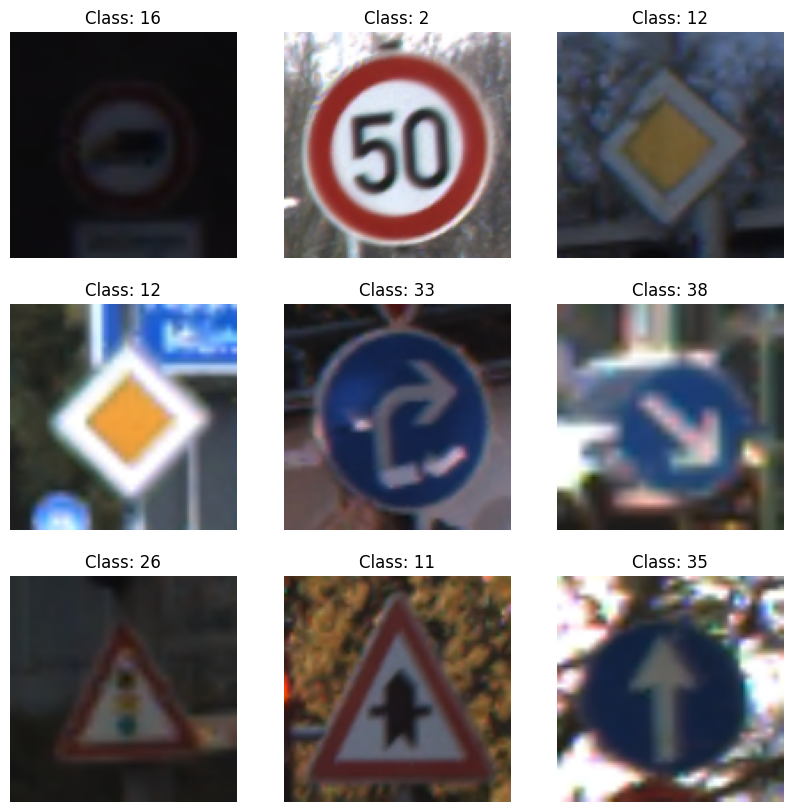

In [11]:
plt.figure(figsize=(10, 10))
for images, labels in train_cnn.take(1): # Take one batch
    for i in range(9): # Display 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Class: {train_cnn.class_names[labels[i]]}")
        plt.axis("off")
plt.show()

In [12]:
from collections import Counter

image_counts_per_class = Counter()

# Iterate through the training dataset to count images per class
for images, labels in train_cnn:
    for label in labels.numpy():
        image_counts_per_class[class_names[label]] += 1

print("Number of images per class in the training dataset:")
for class_name, count in image_counts_per_class.items():
    print(f"  {class_name}: {count} images")

Number of images per class in the training dataset:
  4: 1630 images
  31: 609 images
  38: 1631 images
  14: 607 images
  12: 1704 images
  2: 1821 images
  13: 1719 images
  8: 1135 images
  28: 425 images
  10: 1620 images
  32: 182 images
  40: 283 images
  18: 952 images
  5: 1533 images
  24: 218 images
  1: 1772 images
  25: 1202 images
  27: 178 images
  11: 1023 images
  20: 293 images
  9: 1165 images
  7: 1165 images
  3: 1149 images
  16: 338 images
  23: 412 images
  42: 197 images
  33: 561 images
  34: 332 images
  39: 244 images
  15: 484 images
  17: 904 images
  35: 952 images
  19: 164 images
  26: 477 images
  29: 221 images
  30: 341 images
  37: 163 images
  22: 301 images
  6: 333 images
  21: 255 images
  0: 166 images
  36: 316 images
  41: 191 images


In [13]:
# Are the classes balanced
print("Class distribution in the training dataset:")
for class_name, count in image_counts_per_class.items():
    print(f"  {class_name}: {count} images ({count / len(train_cnn.file_paths) * 100:.2f}%)")

Class distribution in the training dataset:
  4: 1630 images (5.20%)
  31: 609 images (1.94%)
  38: 1631 images (5.20%)
  14: 607 images (1.94%)
  12: 1704 images (5.43%)
  2: 1821 images (5.81%)
  13: 1719 images (5.48%)
  8: 1135 images (3.62%)
  28: 425 images (1.35%)
  10: 1620 images (5.16%)
  32: 182 images (0.58%)
  40: 283 images (0.90%)
  18: 952 images (3.03%)
  5: 1533 images (4.89%)
  24: 218 images (0.69%)
  1: 1772 images (5.65%)
  25: 1202 images (3.83%)
  27: 178 images (0.57%)
  11: 1023 images (3.26%)
  20: 293 images (0.93%)
  9: 1165 images (3.71%)
  7: 1165 images (3.71%)
  3: 1149 images (3.66%)
  16: 338 images (1.08%)
  23: 412 images (1.31%)
  42: 197 images (0.63%)
  33: 561 images (1.79%)
  34: 332 images (1.06%)
  39: 244 images (0.78%)
  15: 484 images (1.54%)
  17: 904 images (2.88%)
  35: 952 images (3.03%)
  19: 164 images (0.52%)
  26: 477 images (1.52%)
  29: 221 images (0.70%)
  30: 341 images (1.09%)
  37: 163 images (0.52%)
  22: 301 images (0.96%)


(128, 128, 3)

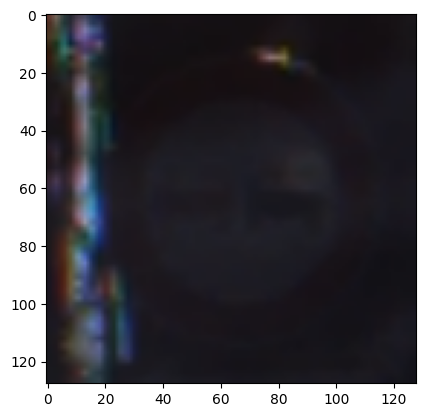

In [14]:
plt.imshow(images[1].numpy().astype("uint8")).get_shape()

## EDA 

In [15]:
print(f"train batches and {tf.data.experimental.cardinality(train_cnn)}, val batches {tf.data.experimental.cardinality(val_cnn)}")


train batches and 981, val batches 246


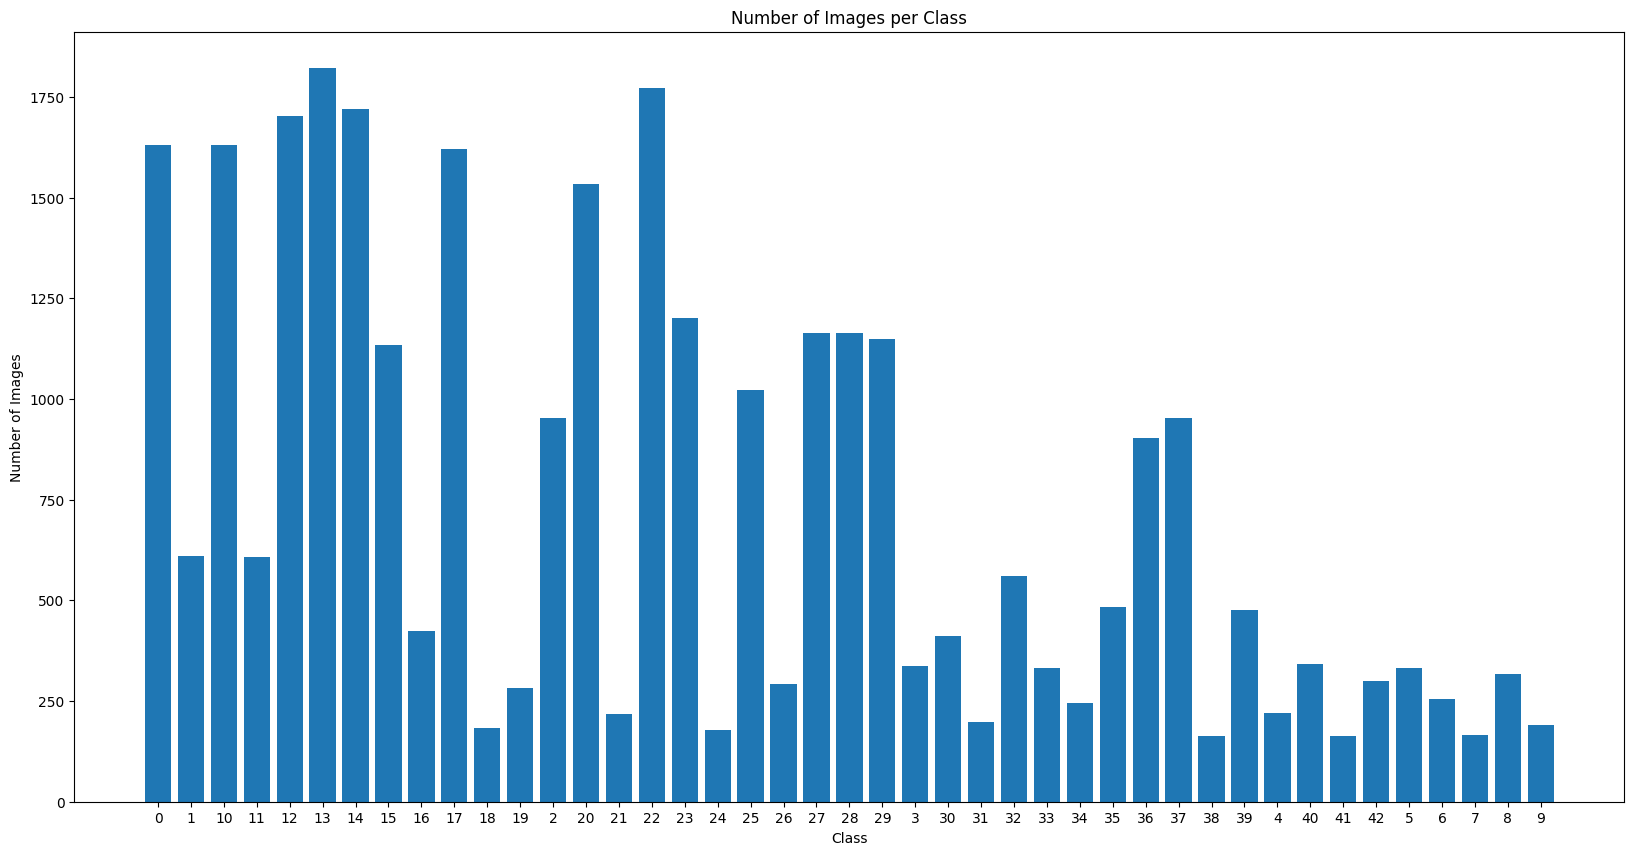

In [ ]:
#bar chart
#Data imbalanced
plt.figure(figsize=(20, 10))
plt.bar(class_names, [count for count in image_counts_per_class.values()])
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Number of Images per Class')
plt.show()

# Parameters & Augmentation

In [ ]:
# Define data augmentation layers
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomBrightness(factor=0.2) # Added a Keras layer for random brightness
])

# Apply data augmentation to the training dataset
# Reshaping (batch_size, classes) for one-hot encoding, f1 score need to (batch_size, classes), (batch_size,)
NUM_CLASSES = 43


train_cnn_onehot = train_cnn.map(
    lambda x, y: (x, tf.one_hot(y, depth=NUM_CLASSES)),
    num_parallel_calls=tf.data.AUTOTUNE
)

val_cnn_onehot = val_cnn.map(
    lambda x, y: (x, tf.one_hot(y, depth=NUM_CLASSES)),
    num_parallel_calls=tf.data.AUTOTUNE
)
# Cache and prefetch all datasets for performance and consistency
train_cnn_onehot = train_cnn_onehot.cache().prefetch(
    buffer_size=tf.data.AUTOTUNE
)

val_cnn_onehot = val_cnn_onehot.cache().prefetch(
    buffer_size=tf.data.AUTOTUNE
)

## Training & Paramters

In [ ]:
# Additionally, you can apply data augmentation to the training dataset as follows:

model = Sequential([
    tf.keras.Input(shape=(128, 128, 3)), # Explicit Input layer
    tf.keras.layers.Rescaling(1./255), # Normalization layer
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),


    Flatten(),
    Dense(128, activation='relu'), # Increased units
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,315 (930.92 KB)

 Trainable params: 238,315 (930.92 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#For data imbalanced ,so accuracy is not a good metric, so we will use F1 score as a metric for evaluation.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=[
        "accuracy",
        tf.keras.metrics.F1Score(average="macro")
    ]
)

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# for saving the best model during training, you can use ModelCheckpoint callback as follows
history = model.fit(
    train_cnn_onehot,
    validation_data=val_cnn_onehot,
    epochs=100, # You can adjust the number of epochs
    callbacks=[early_stopping]
)

Epoch 1/100
981/981 ━━━━━━━━━━━━━━━━━━━━ 33s 25ms/step - accuracy: 0.3337 - f1_score: 0.2133 - loss: 2.2389 - val_accuracy: 0.5781 - val_f1_score: 0.4355 - val_loss: 1.3238
Epoch 2/100
981/981 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.6542 - f1_score: 0.5577 - loss: 1.0547 - val_accuracy: 0.9038 - val_f1_score: 0.8442 - val_loss: 0.3597
Epoch 3/100
981/981 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.8346 - f1_score: 0.7740 - loss: 0.5050 - val_accuracy: 0.9635 - val_f1_score: 0.9518 - val_loss: 0.1428
Epoch 4/100
981/981 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.8988 - f1_score: 0.8590 - loss: 0.3159 - val_accuracy: 0.9793 - val_f1_score: 0.9752 - val_loss: 0.0773
Epoch 5/100
981/981 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9237 - f1_score: 0.8951 - loss: 0.2431 - val_accuracy: 0.9857 - val_f1_score: 0.9815 - val_loss: 0.0609
Epoch 6/100
981/981 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9370 - f1_score: 0.9150 - loss: 0.2012 - val_accuracy: 0.9886 - va

## Saving Model

In [37]:
model.save("cnn_model_customized.keras")